# **Flow Matching on Fashion MNIST: ODE vs SDE Samplings**

## Project overview

This project trains a class- conditional generative model on Fashion-MNIST using flow matching. I compare deterministic ODE sampling and stochastic SDE sampling in terms of their trajectories and outputs.

**Skills demonstrated:** Python, PyTorch, generative modeling, ODE/SDE sampling, U-Net architecture, experiment design, data visualization

**Motivation:** The theory suggests the ODE and SDE samplings using the same trained velocity field should preserve the same marginal distributions while having the different trajectories. I wanted to investigate how they behave in a finite numerical experiment.

**Goal:** Generate a requested clothing class starting from Gaussian noise.

**Main result:** The ODE and SDE samplers produce similar class-conditional distributions, while the SDE introduces additional simple-level randomness.

### Notebook outline

1. Load and normalize Fashion-MNIST
2. Construct probability paths between data and noise
3. Train a conditional U-Net to predict the velocity field
4. Generate images using ODE and SDE samplers
5. Compare image quality, diversity, and sampling behavior

## 1. Setup

This section imports the required libraries, sets random seeds for reproducibility, and selects the best available computing device. *italicized text*



In [ ]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: cuda


The notebook uses CUDA when a compatible GPU is available, Apple MRS on supported Macs, and CPU otherwise.

## 2. Dataset preparation

Fashion-MNIST contains 28x28 px grayscale images frpm ten clothing categories. The images are converted to tensors and normalized from $[0, 1]$ to $[-1, 1]$ for model training.

Additional null class is reserved for classifier-free guidence, allowing the same model to learn both conditional and marginal velocity fields.

In [ ]:
FASHION_CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
NUM_CLASSES = 10
NULL_CLASS = 10  # extra class used for classifier-free guidance

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # [0,1] -> [-1,1]
])

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# num_workers=0 is the most reliable choice in notebooks and on Windows/macOS.
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print("images:", images.shape, "labels:", labels.shape)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.97MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.10MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.1MB/s]

images: torch.Size([128, 1, 28, 28]) labels: torch.Size([128])


A training batch has shape $(128,1,28,28)$ where 128 is the batch size, 1 is the grayscale channel, and 28x28 is the image resolution.

### 2.1 Visualize the dataset

The following helper function converts normalized images back to a visible range and displays them in a grid. The examples confirm that the dataset was loaded and normalized correctly. **bold text**

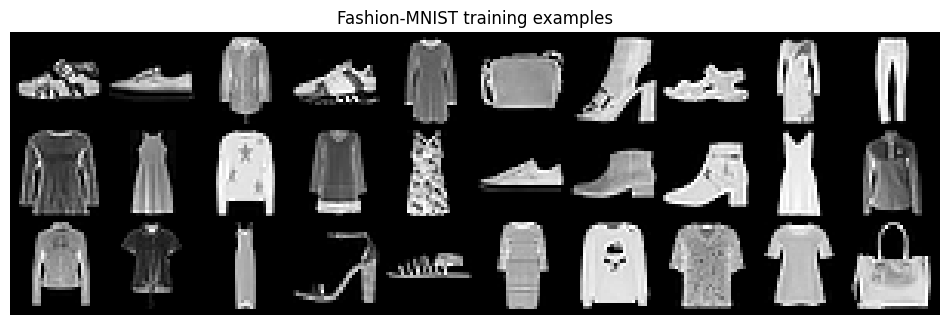

In [ ]:
def show_image_grid(images, labels=None, nrow=10, title=None):
    images = images.detach().cpu().clamp(-1, 1)
    grid = make_grid((images + 1) / 2, nrow=nrow, padding=2)
    plt.figure(figsize=(12, 5))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()

show_image_grid(images[:30], labels[:30], nrow=10, title="Fashion-MNIST training examples")

## 3. Conditional probability path

For each data image $Z$, I sample Gaussian noise $\varepsilon$ and a random time $t$.

The linear conditional path is

$
X_t=(1-t)\varepsilon+tZ
$

At $t=0$, the sample is Gaussian noise. At $t=1$, it reaches the data image.

Because this path is linear, the target conditional velocity is

$
u_t^\star=Z-\varepsilon
$

The model will be trained to predict this velocity from $X_t$, $t$, and the class label.

In [ ]:
def sample_conditional_path(data_images, t=None):
    """Sample (epsilon, t, X_t, target velocity) for the linear CondOT path."""
    batch_size = data_images.shape[0]
    epsilon = torch.randn_like(data_images)

    if t is None:
        # Avoid exact endpoints during training.
        t = torch.rand(batch_size, device=data_images.device) * 0.998 + 0.001
    if t.ndim == 1:
        t_image = t[:, None, None, None]
    else:
        t_image = t

    x_t = (1.0 - t_image) * epsilon + t_image * data_images
    target_velocity = data_images - epsilon
    return epsilon, t.view(batch_size), x_t, target_velocity

### 3.1 Visualizing the probability path

The following experiment fixes several noise-image pairs and evaluates the linear path at different times from $t=0$ to $t=1$.

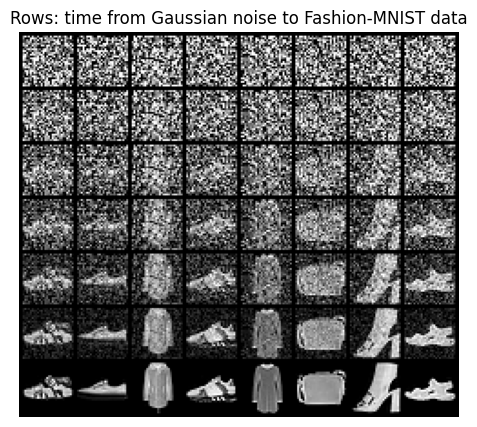

In [ ]:
z = images[:8].to(device)
epsilon = torch.randn_like(z)
t_values = torch.linspace(0, 1, 7, device=device)
path_images = []
for t_value in t_values:
    path_images.append((1 - t_value) * epsilon + t_value * z)
path_images = torch.cat(path_images, dim=0)
show_image_grid(path_images, nrow=8, title="Rows: time from Gaussian noise to Fashion-MNIST data")

Each row begins as Gaussian noise and gradually becomes a Fashion MNIST training image. This is the path the model will learn.

## 4. U-Net architecture

The neural network receives:

- intermediate image $X_t$
- time $t$
- required clothing class

It returns a velocity tensor with the same shape as the image

In [ ]:
# The scaler time value is converted into a higher-dimensional representation.
class FourierTimeEmbedding(nn.Module):
    def __init__(self, embedding_dim=128, max_frequency=1000.0):
        super().__init__()
        assert embedding_dim % 2 == 0
        half = embedding_dim // 2
        frequencies = torch.exp(
            torch.linspace(0, math.log(max_frequency), half)
        )
        self.register_buffer("frequencies", frequencies)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.SiLU(),
            nn.Linear(embedding_dim, embedding_dim),
        )

    def forward(self, t):
        angles = 2 * math.pi * t[:, None] * self.frequencies[None, :]
        features = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)
        return self.mlp(features)


# Each residual block processes image features with convolutional layers and adds information from the combined time and class embedding.
class ConditionalResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, embedding_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.embedding_projection = nn.Linear(embedding_dim, out_channels)
        self.skip = (
            nn.Identity() if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, 1)
        )

    def forward(self, x, embedding):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.embedding_projection(embedding)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


# The U-Net first reduces the spatial resolution to learn higher-level features and then restores the original resolution.
class ConditionalUNet(nn.Module):
    def __init__(self, base_channels=32, embedding_dim=128):
        super().__init__()
        self.time_embedding = FourierTimeEmbedding(embedding_dim)
        self.class_embedding = nn.Embedding(NUM_CLASSES + 1, embedding_dim)
        self.condition_mlp = nn.Sequential(
            nn.SiLU(), nn.Linear(embedding_dim, embedding_dim)
        )

        self.input_conv = nn.Conv2d(1, base_channels, 3, padding=1)

        self.down1 = ConditionalResBlock(base_channels, base_channels, embedding_dim)
        self.downsample1 = nn.Conv2d(base_channels, 2 * base_channels, 4, stride=2, padding=1)
        self.down2 = ConditionalResBlock(2 * base_channels, 2 * base_channels, embedding_dim)
        self.downsample2 = nn.Conv2d(2 * base_channels, 4 * base_channels, 4, stride=2, padding=1)

        self.middle1 = ConditionalResBlock(4 * base_channels, 4 * base_channels, embedding_dim)
        self.middle2 = ConditionalResBlock(4 * base_channels, 4 * base_channels, embedding_dim)

        self.upsample2 = nn.ConvTranspose2d(4 * base_channels, 2 * base_channels, 4, stride=2, padding=1)
        self.up2 = ConditionalResBlock(4 * base_channels, 2 * base_channels, embedding_dim)
        self.upsample1 = nn.ConvTranspose2d(2 * base_channels, base_channels, 4, stride=2, padding=1)
        self.up1 = ConditionalResBlock(2 * base_channels, base_channels, embedding_dim)

        self.output_norm = nn.GroupNorm(8, base_channels)
        self.output_conv = nn.Conv2d(base_channels, 1, 3, padding=1)
        nn.init.zeros_(self.output_conv.weight)
        nn.init.zeros_(self.output_conv.bias)

    def forward(self, x, t, labels):
        embedding = self.time_embedding(t) + self.class_embedding(labels)
        embedding = self.condition_mlp(embedding)

        h0 = self.input_conv(x)          # 28 x 28
        h1 = self.down1(h0, embedding)   # 28 x 28
        h2 = self.downsample1(h1)        # 14 x 14
        h2 = self.down2(h2, embedding)
        h3 = self.downsample2(h2)        # 7 x 7

        h3 = self.middle1(h3, embedding)
        h3 = self.middle2(h3, embedding)

        h = self.upsample2(h3)           # 14 x 14
        h = self.up2(torch.cat([h, h2], dim=1), embedding)
        h = self.upsample1(h)             # 28 x 28
        h = self.up1(torch.cat([h, h1], dim=1), embedding)
        return self.output_conv(F.silu(self.output_norm(h)))

### 4.1 Output-shape check

Because the model predicts one velocity value for every input pixel, its output mush have the same shape as the input image.

In [ ]:
# Shape sanity check: the velocity must have the same shape as X_t.
model = ConditionalUNet().to(device)
test_x = torch.randn(4, 1, 28, 28, device=device)
test_t = torch.rand(4, device=device)
test_y = torch.tensor([0, 1, 9, NULL_CLASS], device=device)
with torch.no_grad():
    test_v = model(test_x, test_t, test_y)
print("input shape:", test_x.shape, "output shape:", test_v.shape)
assert test_v.shape == test_x.shape

input shape: torch.Size([4, 1, 28, 28]) output shape: torch.Size([4, 1, 28, 28])


The input an output both have the same shape $(4,1,28,28)$, confirming that the model produces a complete velocity field for each image in the batch.

##5. Flow matching training

The model is trained by comparing its predicted velocity with the exact velocity of the sampled conditional path.

The training objective is

$
L(\theta)
=
\mathbb{E}
\left[
  \left\|
    u_\theta(X_t, t, y)-u_t^⋆
  \right\|^2
\right]
$

where $u_\theta$ is the velocity predicted by the neural network and $u_t^⋆=Z-ɛ$ is the target velocity.

During training, 10% of labels are replaced by the null class. This teaches the same model to make both class-conditional and unconditional predictions, which will later be used for classifier-free guidence.

In [ ]:
def flow_matching_loss(model, data_images, labels, label_drop_probability=0.1):
    _, t, x_t, target_velocity = sample_conditional_path(data_images)

    dropped_labels = labels.clone()
    drop_mask = torch.rand(labels.shape[0], device=labels.device) < label_drop_probability
    dropped_labels[drop_mask] = NULL_CLASS

    predicted_velocity = model(x_t, t, dropped_labels)
    return F.mse_loss(predicted_velocity, target_velocity)


def train_flow_model(model, train_loader, epochs=20, learning_rate=2e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_examples = 0

        for data_images, labels in train_loader:
            data_images = data_images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            loss = flow_matching_loss(model, data_images, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * data_images.shape[0]
            total_examples += data_images.shape[0]

        epoch_loss = total_loss / total_examples
        history.append(epoch_loss)
        print(f"epoch {epoch:02d} | loss {epoch_loss:.6f}")

    return history

### 5.1 Model optimization

The model is trained for 20 epochs using AdamW.  For each batch, the loss is computed, gradients are obtained through backpropagation, and the model parameters are updated.

epoch 01 | loss 0.473598
epoch 02 | loss 0.273764
epoch 03 | loss 0.254011
epoch 04 | loss 0.245369
epoch 05 | loss 0.239075
epoch 06 | loss 0.236011
epoch 07 | loss 0.231191
epoch 08 | loss 0.230197
epoch 09 | loss 0.228185
epoch 10 | loss 0.225183
epoch 11 | loss 0.223152
epoch 12 | loss 0.222268
epoch 13 | loss 0.221081
epoch 14 | loss 0.220239
epoch 15 | loss 0.219063
epoch 16 | loss 0.216993
epoch 17 | loss 0.216690
epoch 18 | loss 0.215696
epoch 19 | loss 0.215186
epoch 20 | loss 0.215235


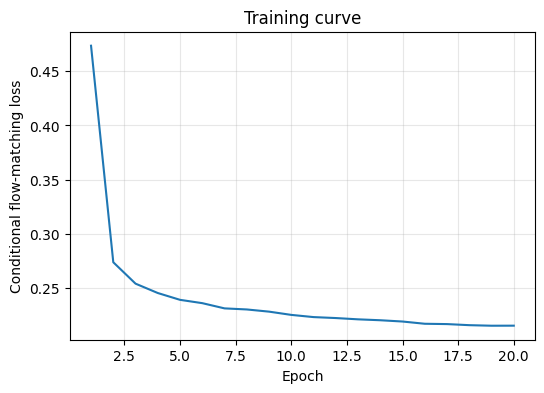

In [ ]:
# Training cell. Run this once; increase epochs if the generated images remain weak.
# On CPU this can be slow. A CUDA GPU is strongly recommended.

EPOCHS = 20
history = train_flow_model(model, train_loader, epochs=EPOCHS, learning_rate=2e-4)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(history) + 1), history)
plt.xlabel("Epoch")
plt.ylabel("Conditional flow-matching loss")
plt.title("Training curve")
plt.grid(alpha=0.3)
plt.show()

Path("checkpoints").mkdir(exist_ok=True)
torch.save(model.state_dict(), "checkpoints/fashion_flow_model.pt")

## 6. Classifier-free guidance

Classifier-free guidance combines the conditional and unconditional velocity predictions.

$
u_{\text{guided}}
=
u_{\text{uncond}}
+
w\left(
  u_{\text{cond}}-u_{\text{uncond}}
\right)
$

where $w$ is the guidance scale.

When $w=1$, the result equals the conditional prediction. Larger values push the sampling direction more strongly toward the requested class.

In [ ]:
def guided_velocity(model, x, t, labels, guidance_scale=1.0):
    conditional = model(x, t, labels)
    if guidance_scale == 1.0:
        return conditional

    null_labels = torch.full_like(labels, NULL_CLASS)
    unconditional = model(x, t, null_labels)
    return unconditional + guidance_scale * (conditional - unconditional)

## 7. Deterministic ODE sampling

Generation begins from Gaussian noise and numerically follows the learned velocity field.

The ODE is approximated using Euler's method

$
X_{k+1}
=
X_k+\Delta t\,u_{\text{guided}}(X_k, t_k)
$

For a fixed initial noise, labels, guidance scale, and number of steps, this sampler is deterministic.

In [ ]:
@torch.no_grad()
def sample_ode(model, labels, num_steps=100, guidance_scale=2.0, initial_noise=None,
               return_trajectory=False):
    model.eval()
    batch_size = labels.shape[0]
    x = (
        torch.randn(batch_size, 1, 28, 28, device=device)
        if initial_noise is None else initial_noise.clone().to(device)
    )

    dt = 1.0 / num_steps
    trajectory = [x.detach().cpu()] if return_trajectory else None

    for k in range(num_steps):
        t = torch.full((batch_size,), k / num_steps, device=device)
        velocity = guided_velocity(model, x, t, labels, guidance_scale)
        x = x + dt * velocity
        if return_trajectory:
            trajectory.append(x.detach().cpu())

    return (x, trajectory) if return_trajectory else x

### 7.1 Class-conditional ODE samples

The following experiment generates four examples of each Fashion-MNIST class. Each column corresponds to one requested class.

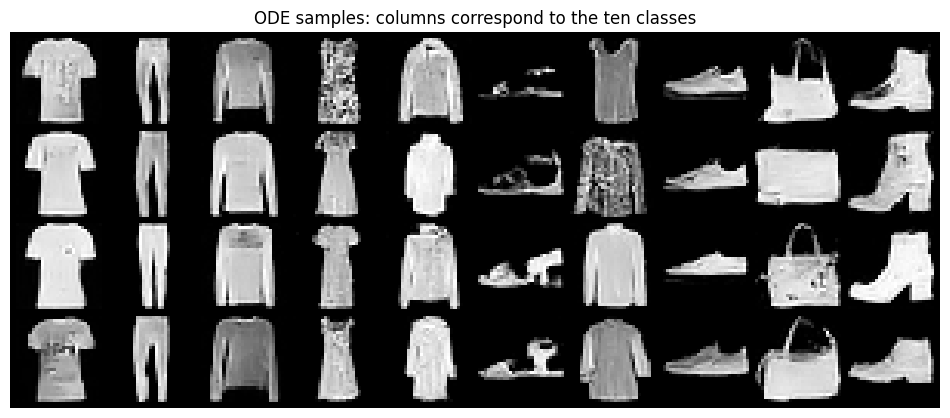

In [ ]:
# One sample per class, repeated across rows.
labels_to_generate = torch.arange(10, device=device).repeat(4)
initial_noise = torch.randn(40, 1, 28, 28, device=device)
ode_samples = sample_ode(
    model, labels_to_generate, num_steps=100,
    guidance_scale=2.0, initial_noise=initial_noise
)
show_image_grid(ode_samples, nrow=10, title="ODE samples: columns correspond to the ten classes")

The generated samples generally follow the requested columns, although some of them, like the first sample for the shirt, has a bit of confusion and the edges are still noisy. Also, categories such as t-shirt, dress, and shirt have the uniqueness for each sample due to the different initial noise.

## 8. Stochastic SDE sampling

To construct the stochatic sampler, the score function is recovered from the learned velocity field.

For the linear path used in thie project, the score is recovered as
$
s_t(x)
=
\frac{t\,u_t(x)-x}{1-t}
$

The denominator is clipped near $t=1$ in the implementation to avoid numerical instability.

In [ ]:
def score_from_velocity(x, t, velocity, minimum_denominator=1e-5):
    t_image = t[:, None, None, None]
    denominator = (1.0 - t_image).clamp_min(minimum_denominator)
    return (t_image * velocity - x) / denominator

### 8.1 Diffusion coefficient and Euler-Maruyama updata

The time-dependent diffusion coefficient is

$
\sigma(t)
=
\sigma_{\max}\sqrt{t(1-t)}
$

It is zerp at the beginning and end of the path and largest near the middle.

The sampler uses the drift

$
b_t(X_k) = u_t(x)+\frac{1}{2}\sigma(t)^2s_t(x)
$

and adds Gaussian Brownian noise at each numerical step. Euler-Maruyama approximates the SDE using

$
X_{k+1}
=
X_k
+
\Delta t\,b_t(X_k)
+
\sigma(t_k)\sqrt{\Delta t}\,\xi_k
$

where $\xi_k$ is standard Gaussian noise.

In [ ]:
def diffusion_coefficient(t, sigma_max):
    return sigma_max * torch.sqrt((t * (1.0 - t)).clamp_min(0.0))


@torch.no_grad()
def sample_marginal_sde(model, labels, num_steps=100, guidance_scale=2.0,
                        sigma_max=1.0, initial_noise=None, brownian_seed=None,
                        return_trajectory=False):
    model.eval()
    batch_size = labels.shape[0]
    x = (
        torch.randn(batch_size, 1, 28, 28, device=device)
        if initial_noise is None else initial_noise.clone().to(device)
    )

    generator = None
    if brownian_seed is not None and device.type == "cpu":
        generator = torch.Generator(device="cpu").manual_seed(brownian_seed)
    elif brownian_seed is not None:
        # Use a local fork so repeated experiments can use controlled Brownian noise.
        torch.manual_seed(brownian_seed)

    dt = 1.0 / num_steps
    sqrt_dt = math.sqrt(dt)
    trajectory = [x.detach().cpu()] if return_trajectory else None

    for k in range(num_steps):
        t = torch.full((batch_size,), k / num_steps, device=device)
        velocity = guided_velocity(model, x, t, labels, guidance_scale)
        score = score_from_velocity(x, t, velocity)
        sigma = diffusion_coefficient(t, sigma_max)
        sigma_image = sigma[:, None, None, None]

        drift = velocity + 0.5 * sigma_image.square() * score
        noise = torch.randn(x.shape, device=device, generator=generator)
        x = x + dt * drift + sqrt_dt * sigma_image * noise

        if return_trajectory:
            trajectory.append(x.detach().cpu())

    return (x, trajectory) if return_trajectory else x

## 9. ODE and SDE comparison

To make the comparison fair, both samplers begin from the same initial Gaussian noise, use the same class labels, use the same trained model, and use the same number of numerical steps.

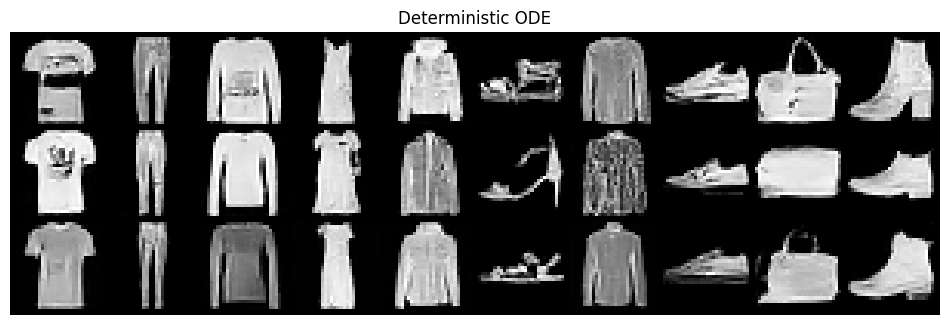

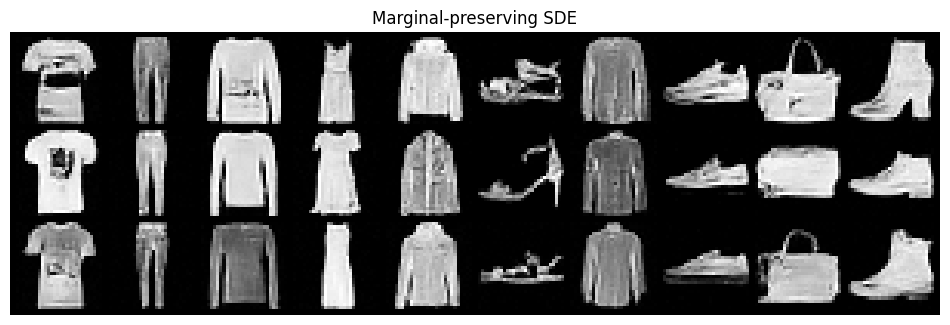

In [ ]:
comparison_labels = torch.arange(10, device=device).repeat(3)
comparison_noise = torch.randn(30, 1, 28, 28, device=device)

ode_samples = sample_ode(
    model, comparison_labels, num_steps=100,
    guidance_scale=2.0, initial_noise=comparison_noise
)
sde_samples = sample_marginal_sde(
    model, comparison_labels, num_steps=100,
    guidance_scale=2.0, sigma_max=1.0,
    initial_noise=comparison_noise, brownian_seed=123
)

show_image_grid(ode_samples, nrow=10, title="Deterministic ODE")
show_image_grid(sde_samples, nrow=10, title="Marginal-preserving SDE")

The two samplers can produce similar class-level structures, indicating the similar marginal disuributions, while still producing different individual images. SDE still has a detailed outputs for some of the results.

### 9.1 Comparing individual trajectories

The following experiment begins both samplers from the same noise image and targets the ankle-boot class. Eight intermediate frames are selected from each trajectory.

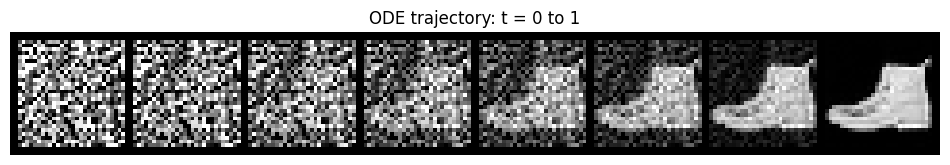

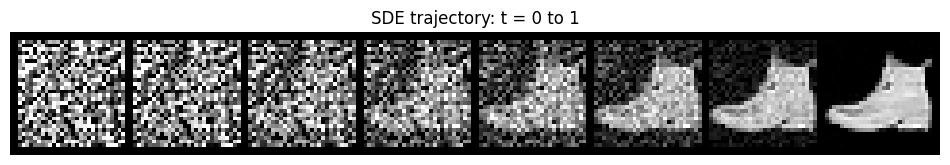

In [ ]:
def select_trajectory_frames(trajectory, num_frames=8):
    indices = np.linspace(0, len(trajectory) - 1, num_frames).round().astype(int)
    return torch.cat([trajectory[i] for i in indices], dim=0)

single_label = torch.tensor([9], device=device)  # ankle boot
single_noise = torch.randn(1, 1, 28, 28, device=device)

_, ode_trajectory = sample_ode(
    model, single_label, num_steps=100, guidance_scale=2.0,
    initial_noise=single_noise, return_trajectory=True
)
_, sde_trajectory = sample_marginal_sde(
    model, single_label, num_steps=100, guidance_scale=2.0,
    sigma_max=1.0, initial_noise=single_noise,
    brownian_seed=77, return_trajectory=True
)

ode_frames = select_trajectory_frames(ode_trajectory, num_frames=8)
sde_frames = select_trajectory_frames(sde_trajectory, num_frames=8)
show_image_grid(ode_frames, nrow=8, title="ODE trajectory: t = 0 to 1")
show_image_grid(sde_frames, nrow=8, title="SDE trajectory: t = 0 to 1")

The ODE follows a smooth deterministic sequence once the initial noise is fixed. The SDE trajectory receives new randomness at every step, so its intermediate steps were shaking more even when its final class remains recognizable.

### 9.2 Effect of the diffusion strength

This experiment varies $\sigma_{max}$ while keeping the initial noise, class, label, Brownian seed, guidance scale, and step count fixed.

When $\sigma_{\max}=0$, the stochastic term disappears and the sampler reduces to the ODE update used. Larger values introdue stronger stochastic impact during samplings.

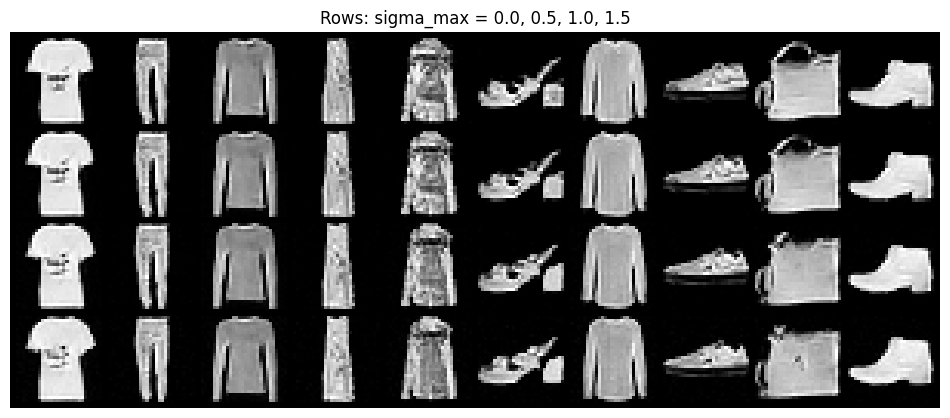

In [ ]:
# Compare several stochasticity levels while holding initial noise fixed.
sigma_values = [0.0, 0.5, 1.0, 1.5]
labels_small = torch.arange(10, device=device)
noise_small = torch.randn(10, 1, 28, 28, device=device)

all_samples = []
for sigma_max in sigma_values:
    samples = sample_marginal_sde(
        model, labels_small, num_steps=100,
        guidance_scale=2.0, sigma_max=sigma_max,
        initial_noise=noise_small, brownian_seed=500
    )
    all_samples.append(samples)

show_image_grid(
    torch.cat(all_samples, dim=0), nrow=10,
    title="Rows: sigma_max = 0.0, 0.5, 1.0, 1.5"
)

Increasing $\sigma_{max}$ changes the individual outputs while preserving their intended classes. Large diffusion may also introduce additional roughness or reduce visual consistency.

###9.3 Effect of the Euler steps

Euler's methos only approximates the continuous ODE. This experiment tests 10, 25, 50, and 100 steps while holding the initial noise and class labels fixed.

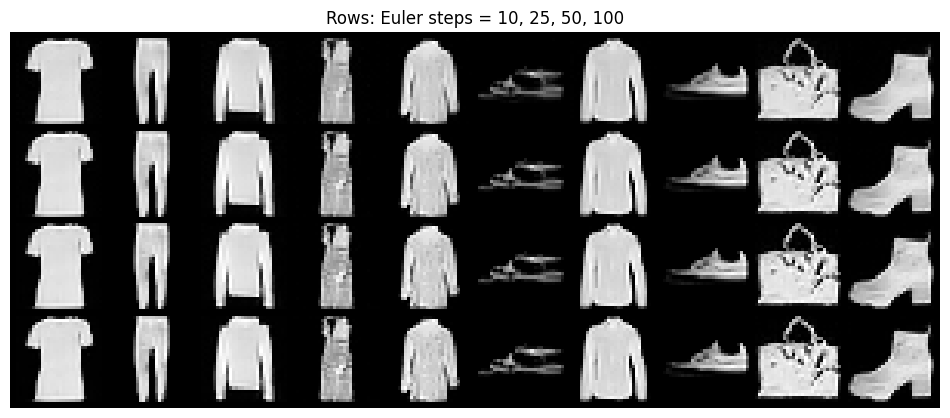

In [ ]:
# Finite-step sensitivity for the deterministic solver.
step_counts = [10, 25, 50, 100]
labels_steps = torch.arange(10, device=device)
noise_steps = torch.randn(10, 1, 28, 28, device=device)
step_samples = []

for num_steps in step_counts:
    step_samples.append(sample_ode(
        model, labels_steps, num_steps=num_steps,
        guidance_scale=2.0, initial_noise=noise_steps
    ))

show_image_grid(
    torch.cat(step_samples, dim=0), nrow=10,
    title="Rows: Euler steps = 10, 25, 50, 100"
)

Using more steps reduce the size of each Euler update and generally gives a more accurate numerical approximation. However, improvements may become small after a sufficient number of steps, while computation continues to increase.

##10. Quantitative comparison

I also calculate two simple image-space metrics for each class.

###10.1 Average pairwise distance

Each image is flattened into a vector. I compute the normalized Euclidean distance between every pair of generated images from the same class and take the average.

A larger value indicates greater pixel-level variation within that class. It does not guarantee meaningful semantic diversity or high image quality.

###10.2 Average total variation

Total variation measures absolute differences between neighboring pixels in the horizontal and vertical directions.

A larger value indicates more local pixel change and may correspond to sharper details, noise, or roughness. It shouldn't be treated as a complete image-quality score.

In [ ]:
def average_pairwise_distance(samples):
    flat = samples.flatten(1)
    distances = torch.pdist(flat, p=2) / math.sqrt(flat.shape[1])
    return distances.mean().item()


def average_total_variation(samples):
    vertical = (samples[:, :, 1:, :] - samples[:, :, :-1, :]).abs().mean()
    horizontal = (samples[:, :, :, 1:] - samples[:, :, :, :-1]).abs().mean()
    return (vertical + horizontal).item()


@torch.no_grad()
def compare_dynamics_by_class(model, samples_per_class=32, num_steps=100,
                              guidance_scale=2.0, sigma_max=1.0):
    rows = []
    for class_id, class_name in enumerate(FASHION_CLASS_NAMES):
        labels = torch.full((samples_per_class,), class_id, device=device, dtype=torch.long)
        initial_noise = torch.randn(samples_per_class, 1, 28, 28, device=device)

        ode = sample_ode(
            model, labels, num_steps=num_steps,
            guidance_scale=guidance_scale, initial_noise=initial_noise
        )
        sde = sample_marginal_sde(
            model, labels, num_steps=num_steps,
            guidance_scale=guidance_scale, sigma_max=sigma_max,
            initial_noise=initial_noise, brownian_seed=1000 + class_id
        )

        rows.append({
            "class": class_name,
            "ODE pairwise distance": average_pairwise_distance(ode),
            "SDE pairwise distance": average_pairwise_distance(sde),
            "ODE total variation": average_total_variation(ode),
            "SDE total variation": average_total_variation(sde),
        })
    return rows

summary_rows = compare_dynamics_by_class(model)
for row in summary_rows:
    print(row)

{'class': 'T-shirt/top', 'ODE pairwise distance': 0.554236888885498, 'SDE pairwise distance': 0.5529309511184692, 'ODE total variation': 0.35504215955734253, 'SDE total variation': 0.3587459325790405}
{'class': 'Trouser', 'ODE pairwise distance': 0.41836103796958923, 'SDE pairwise distance': 0.4170049726963043, 'ODE total variation': 0.2923428416252136, 'SDE total variation': 0.30587178468704224}
{'class': 'Pullover', 'ODE pairwise distance': 0.5965622663497925, 'SDE pairwise distance': 0.6170714497566223, 'ODE total variation': 0.38306689262390137, 'SDE total variation': 0.3964022397994995}
{'class': 'Dress', 'ODE pairwise distance': 0.519228458404541, 'SDE pairwise distance': 0.5137953758239746, 'ODE total variation': 0.2752234935760498, 'SDE total variation': 0.28567326068878174}
{'class': 'Coat', 'ODE pairwise distance': 0.5429956912994385, 'SDE pairwise distance': 0.5435130000114441, 'ODE total variation': 0.3617498576641083, 'SDE total variation': 0.3723452091217041}
{'class': 'S

The matrics are computed separately for every clothing class because the natural variation and texture differ across categories.

###10.3 Within-class diversity results

The following chart compares the average pairwise distance of ODE and SDE samples for each class.

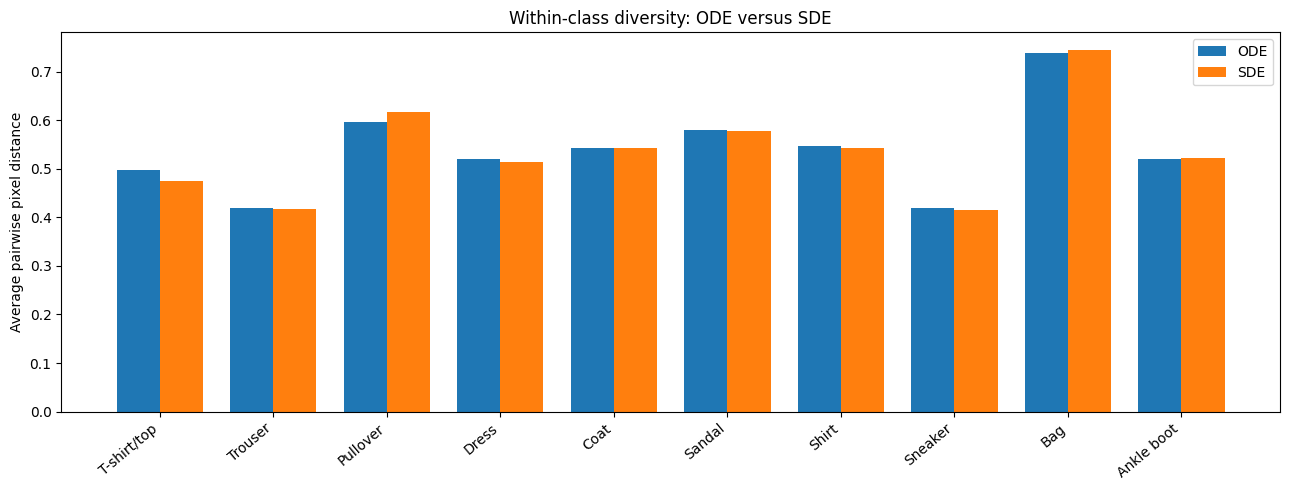

In [ ]:
# Plot classwise diversity comparison.
class_names = [row["class"] for row in summary_rows]
ode_diversity = [row["ODE pairwise distance"] for row in summary_rows]
sde_diversity = [row["SDE pairwise distance"] for row in summary_rows]

x_positions = np.arange(NUM_CLASSES)
width = 0.38
plt.figure(figsize=(13, 5))
plt.bar(x_positions - width / 2, ode_diversity, width, label="ODE")
plt.bar(x_positions + width / 2, sde_diversity, width, label="SDE")
plt.xticks(x_positions, class_names, rotation=40, ha="right")
plt.ylabel("Average pairwise pixel distance")
plt.title("Within-class diversity: ODE versus SDE")
plt.legend()
plt.tight_layout()
plt.show()

The SDE has higher pairwise distance for pullover, while mostly both doesn't have much significant difference.

###10.4 Local image variation results

The following chart compares average total variation between the two samplers for each class.

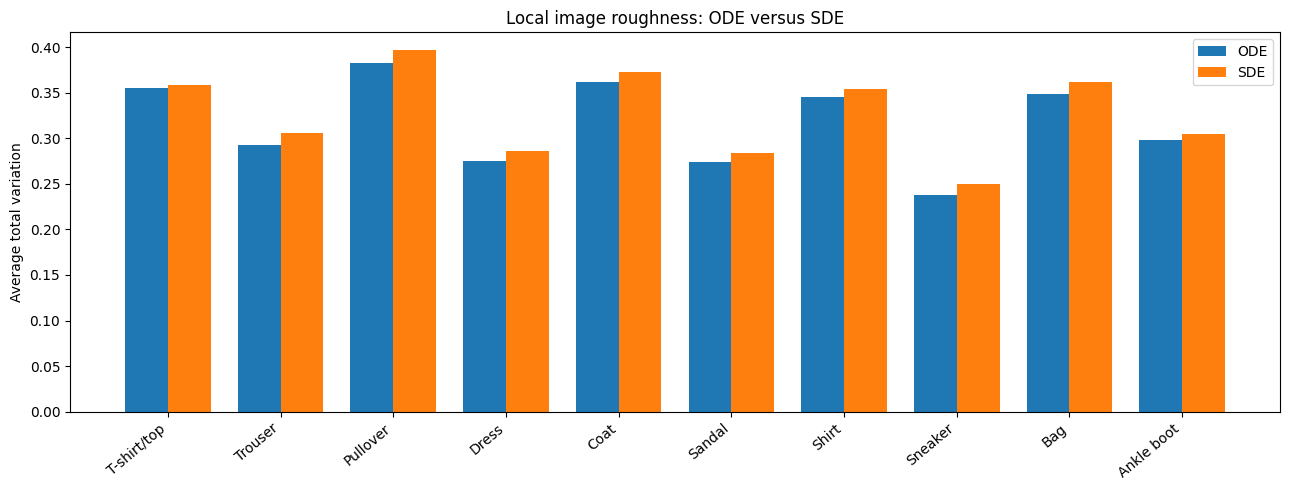

In [ ]:
# Plot classwise total variation comparison.
class_names = [row["class"] for row in summary_rows]
ode_total_variation = [row["ODE total variation"] for row in summary_rows]
sde_total_variation = [row["SDE total variation"] for row in summary_rows]

x_positions = np.arange(NUM_CLASSES)
width = 0.38

plt.figure(figsize=(13, 5))
plt.bar(
    x_positions - width / 2,
    ode_total_variation,
    width,
    label="ODE"
)
plt.bar(
    x_positions + width / 2,
    sde_total_variation,
    width,
    label="SDE"
)

plt.xticks(x_positions, class_names, rotation=40, ha="right")
plt.ylabel("Average total variation")
plt.title("Local image roughness: ODE versus SDE")
plt.legend()
plt.tight_layout()
plt.show()

SDE tends to have higher average total variation for all classes. Higher total variation means stronger neighboring-pixel differences, but it can reflect either useful detail or unwanted noise.

##11. Main findings

1. The conditional flow-matching model generated recognizable examples from multiple Fashion-MNIST classes.

2. The ODE sampler was deterministic when the initial noise and settings were fixed, while the SDE sampler produced different trajectories through Brownian noise.

3. ODE and SDE samples showed similar class-level behavior, but their individual outputs and image-space metrics differed.

4. Increasing the number of Euler steps improved numerical stability, with diminishing visible changes at larger step counts.

5. The effects of stochasticity varied by clothing class rather than producing one uniform improvement.

##12. Limitations

1. Fashion-MNIST contains small 28x28 grayscale images, so these results do not demonstrate performance on complex natural images.

2. The model was trained for a limited number of epochs and maynot generate every class equally well.

3. Pairwise pixel distance and total variation are only rough matrics. They do not directly measure accuracy or quality.

4. The ODE and SDE are solved using finite number of numerical steps, so the theorical continuous-time behavior is only approximated.

5. Results depend on random initialization, initial noise, Brownian noise, guidence strength, diffusion strength, and training resources.

##13. Conclusion

This project implemented a class-conditional flow-matching model for Fashion-MNIST and used the learned velocity field with both deterministic ODE sampling and stochastic SDE sampling.

The project helped me connect the mathematical relationship among probability paths, velocity fields, score functions, and numerical sampling with a complete PyTorch implementation. The experiments also showed why fair comparisons require controlling the initial noise, class labels, guidance scale, and numerical step count.

Future work could include evaluating class accuracy with a pretrained classifier, using stronger perceptual metrics, tuning the U-Net, and testing the method on a more complex image dataset.